In [ ]:
!pip install pystac-client rasterio geopandas pyproj matplotlib numpy pandas

In [2]:
import os
from pystac_client import Client
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd

In [3]:
# Normalize a GeoJSON Feature/FeatureCollection/geometry into a bare geometry dict for `intersects=`.
def handle_feature_collection(feature_collection):
    geo_type = feature_collection["type"]
    if geo_type not in ["Point", "Polygon", "Feature", "FeatureCollection"]:
        raise ValueError("Only Point, Polygon, Feature, and FeatureCollection types are supported.")

    if geo_type == "FeatureCollection":
        return feature_collection["features"][0]["geometry"]
    if geo_type == "Feature":
        return feature_collection["geometry"]
    return feature_collection

In [4]:
def search_items(
    stac_url: str,
    collection: str,
    datetime: str | None = None,
    feature_collection: dict | None = None,
    limit: int = 10,
):
    """Search a STAC collection on this system's STAC API.

    stac_url: e.g. 'http://localhost/stac' or 'https://e-safari.acmad.org/stac'.
    datetime: ISO 8601 instant or interval, e.g. '2026-01-01/2026-06-30'.
    feature_collection: optional GeoJSON Feature/FeatureCollection/geometry for spatial filtering.
    """
    client = Client.open(stac_url)
    kwargs = {"collections": [collection], "limit": limit, "max_items": limit}
    if datetime:
        kwargs["datetime"] = datetime
    if feature_collection:
        kwargs["intersects"] = handle_feature_collection(feature_collection)

    search = client.search(**kwargs)
    items = list(search.items())
    print(f"Found {len(items)} items")
    return items

In [5]:
# Define a GeoJSON feature collection for the search
feature_collection = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              35.091792388971584,
              0.5900286891046989
            ],
            [
              35.091792388971584,
              0.5741557135470998
            ],
            [
              35.123369292604906,
              0.5741557135470998
            ],
            [
              35.123369292604906,
              0.5900286891046989
            ],
            [
              35.091792388971584,
              0.5900286891046989
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}

gdf = gpd.GeoDataFrame.from_features(feature_collection["features"])
bbox = gdf.total_bounds

In [6]:
ENV = "local"  # switch to "prod" to point this notebook at the production system

STAC_URLS = {
    "local": "http://localhost/stac",
    "prod": "https://e-safari.acmad.org/stac",
}
# MinIO/S3 endpoint used by rasterio's /vsis3/ driver to read the actual raster bytes
# behind a STAC asset href (assets are s3://bucket/key URIs, not plain HTTPS).
S3_ENDPOINTS = {
    "local": "localhost:9000",
    "prod": "minio.acmad.org",
}

stac_url = STAC_URLS[ENV]

# The `geodata` bucket has a public anonymous-read policy (s3:GetObject for Principal: *),
# since these datasets are meant to be publicly readable. No MinIO credentials needed -
# AWS_NO_SIGN_REQUEST tells GDAL to skip request signing entirely. If a dataset is ever
# NOT meant to be public, this must switch to scoped read-only credentials (never root/admin).
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["AWS_S3_ENDPOINT"] = S3_ENDPOINTS[ENV]
os.environ["AWS_HTTPS"] = "YES" if ENV == "prod" else "NO"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"

print("STAC URL:  ", stac_url)
print("S3 endpoint:", os.environ["AWS_S3_ENDPOINT"])

STAC URL:   http://localhost/stac
S3 endpoint: localhost:9000


In [7]:
items = search_items(
    stac_url,
    collection="precipitation-percentile-cpc-uni",
    feature_collection=feature_collection,
)
for item in items:
    print(item.id, item.datetime)

Found 1 items
precipitation-percentile-cpc-uni_2026-04-28T0000000000 2026-04-28 00:00:00+00:00


ID:       precipitation-percentile-cpc-uni_2026-04-28T0000000000
Datetime: 2026-04-28 00:00:00+00:00
BBox:     [-25.5, -40.5, 60.5, 40.5]
Assets:   ['data']
HREF:     s3://geodata/precipitation-percentile-cpc-uni/2026/06/b7e7a512-1baf-4976-9f41-98e91c118263-AFR_Apr_2026_CPC-UNI_Percentile.tif
driver: GTiff shape: (162, 172) dtype: ('float32',) crs: EPSG:4326


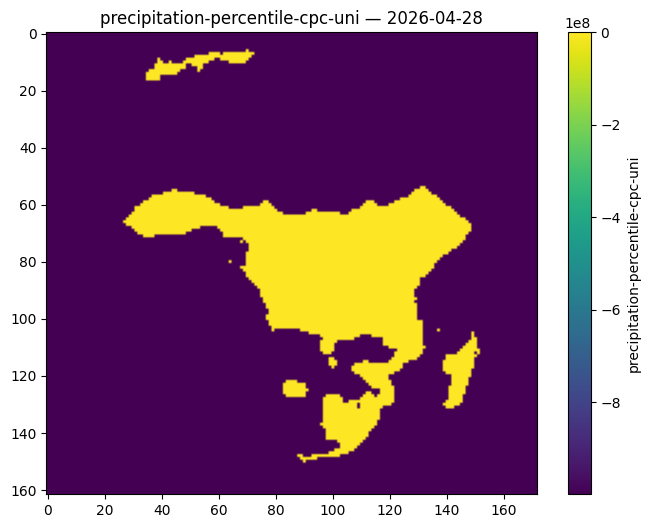

In [8]:
# --- Given just a STAC URL + collection id + item id, fetch the item and read its raster ---
# This is the shape an external user/AI-analysis component would use: no prior knowledge
# needed beyond (stac_url, collection_id, item_id).

collection_id = "precipitation-percentile-cpc-uni"
if not items:
    raise RuntimeError("No STAC items found; adjust collection/datetime/spatial filters.")
item_id = items[0].id

catalog = Client.open(stac_url)
item = catalog.get_collection(collection_id).get_item(item_id)

print("ID:      ", item.id)
print("Datetime:", item.datetime)
print("BBox:    ", item.bbox)
print("Assets:  ", list(item.assets.keys()))

href = item.assets["data"].href
print("HREF:    ", href)

# Asset hrefs are s3://bucket/key URIs into MinIO, not plain HTTPS - GDAL's /vsis3/
# driver resolves them into a real raster read using the AWS_* env vars set above.
vsi_path = "/vsis3/" + href.replace("s3://", "")
with rasterio.open(vsi_path) as src:
    print("driver:", src.driver, "shape:", src.shape, "dtype:", src.dtypes, "crs:", src.crs)
    band = src.read(1, masked=True)

plt.figure(figsize=(8, 6))
plt.imshow(band, cmap="viridis")
plt.colorbar(label=collection_id)
plt.title(f"{collection_id} — {item.datetime.date()}")
plt.show()